# 07 — Framing and Bias

> **"The same data can tell opposite stories depending on how you frame it."**

---

Visualization không bao giờ trung lập hoàn toàn.
Mọi lựa chọn thiết kế — trục bắt đầu từ đâu, khoảng thời gian nào được chọn,
đơn vị nào được dùng — đều là một hành động **framing**.

Framing tốt = làm rõ insight thật sự.
Framing xấu (dù vô tình hay cố ý) = misleading visualization.

Notebook này không dạy cách tạo misleading charts —
nó dạy cách **nhận ra** chúng để không bị đánh lừa, và không vô tình tạo ra chúng.

### Nội dung notebook này:

1. **Truncated Y-Axis** — Phóng đại thay đổi nhỏ
2. **Cherry-Picking Time Window** — Chọn khoảng thời gian có lợi
3. **Percentage vs Absolute** — Cùng số, khác câu chuyện
4. **Dual Axis Manipulation** — Tạo correlation giả
5. **Cumulative vs Period** — Che giấu sự chậm lại
6. **Sample Size Blindness** — Tỷ lệ % mà không nói n
7. **Misleading Baseline** — Area chart không từ 0
8. **Simpson's Paradox** — Trend bị đảo chiều khi aggregate
9. **Honest Chart Checklist**

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

matplotlib.use('Agg')
%matplotlib inline

import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from vizint.core import ChartBuilder, despine, set_grid
from vizint.core.axes_utils import format_percent, format_thousands, set_tick_style
from vizint.annotation import add_note, add_caption, annotate_with_arrow
from vizint.context import add_reference_line
from vizint.styling import categorical_colors
from vizint.styling.typography import TITLE_SIZE, CAPTION_SIZE

np.random.seed(42)

# ── Helper: side-by-side bad vs good ─────────────────────────────
def make_pair(title_bad, title_good, figsize=(14, 4)):
    fig, axes = plt.subplots(1, 2, figsize=figsize, facecolor='white')
    for ax, title, tag, color in zip(
        axes,
        [title_bad, title_good],
        ['❌  Misleading', '✓  Honest'],
        ['#DC2626', '#16A34A'],
    ):
        ax.set_title(f'{tag}\n{title}',
                     loc='left', fontsize=9, fontweight='bold', color=color)
        despine(ax); set_grid(ax)
    return fig, axes

print('Setup OK ✓')

Setup OK ✓


## Synthetic Data

Một tập dữ liệu dùng xuyên suốt: **monthly revenue 48 tháng** với tăng trưởng chậm nhưng đều.

In [2]:
T = 48
months = np.arange(T)

# Slow but steady growth
revenue   = 1000 + months * 2.5 + np.random.randn(T) * 8
product_a = 500  + months * 3.0 + np.random.randn(T) * 10   # revenue $K
product_b = 80   + months * 0.4 + np.random.randn(T) * 2    # units sold

print(f'Revenue  : {T} months, range [{revenue.min():.0f}, {revenue.max():.0f}]')
print(f'Product A: [{product_a.min():.0f}, {product_a.max():.0f}] $K')
print(f'Product B: [{product_b.min():.0f}, {product_b.max():.0f}] units')

Revenue  : 48 months, range [1001, 1126]
Product A: [485, 639] $K
Product B: [79, 101] units


---
## 1. Truncated Y-Axis

**Kỹ thuật:** Bắt đầu trục y từ một giá trị khác 0 — thường là gần với giá trị nhỏ nhất của data.

**Hiệu ứng:** Biến đổi nhỏ trông như biến đổi lớn. Slope của đường trông dốc hơn thực tế.

**Khi nào có thể dùng y-axis không từ 0:**
- Line chart đo sự thay đổi (không phải magnitude) — nhiệt độ, GDP growth rate
- Khi 0 không có ý nghĩa tham chiếu trong context

**Khi nào PHẢI bắt đầu từ 0:** Bar chart và area chart — luôn luôn.

C:\Users\Duy\AppData\Local\Temp\ipykernel_27540\490714634.py:25: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
c:\Users\Duy\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


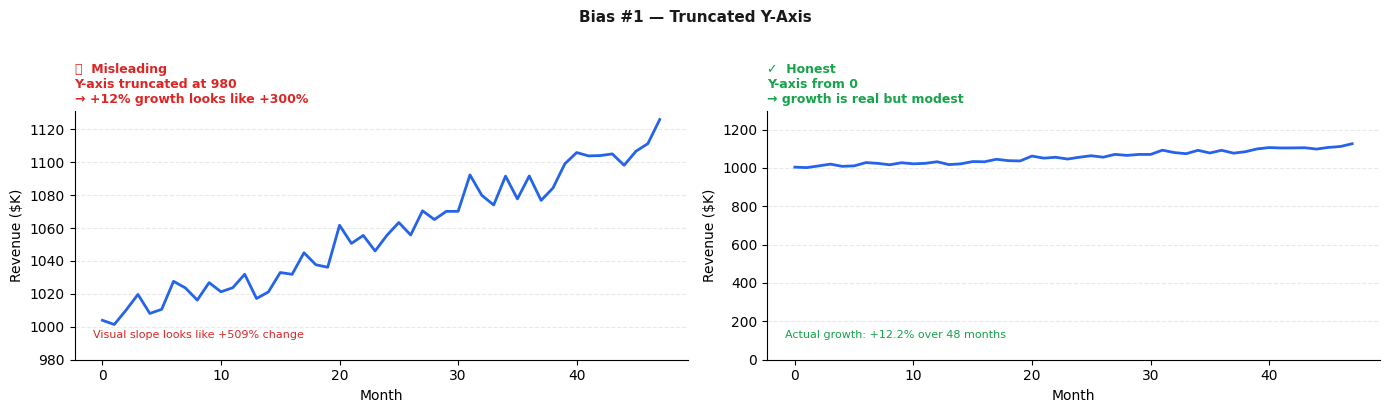

In [3]:
fig, axes = make_pair(
    'Y-axis truncated at 980\n→ +12% growth looks like +300%',
    'Y-axis from 0\n→ growth is real but modest'
)

# Misleading: truncated
ax = axes[0]
ax.plot(months, revenue, color='#2563EB', linewidth=2.0)
ax.set_ylim(980, revenue.max() + 5)
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($K)')
add_note(ax, f'Visual slope looks like +{(revenue[-1]-980)/(revenue[0]-980)*100-100:.0f}% change',
         x=0.03, y=0.12, color='#DC2626', fontsize=8)

# Honest: from zero
ax = axes[1]
ax.plot(months, revenue, color='#2563EB', linewidth=2.0)
ax.set_ylim(0, revenue.max() * 1.15)
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($K)')
actual_pct = (revenue[-1] - revenue[0]) / revenue[0] * 100
add_note(ax, f'Actual growth: +{actual_pct:.1f}% over {T} months',
         x=0.03, y=0.12, color='#16A34A', fontsize=8)

fig.suptitle('Bias #1 — Truncated Y-Axis',
             fontsize=11, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Cherry-Picking Time Window

**Kỹ thuật:** Chọn khoảng thời gian bắt đầu / kết thúc có lợi cho narrative muốn kể.

**Ví dụ thực tế:**
- "Cổ phiếu tăng 40% trong 6 tháng qua" — nhưng bỏ qua việc nó giảm 60% trước đó
- "Tỷ lệ tội phạm giảm kể từ khi chính sách X" — nhưng trend đã giảm từ trước đó rồi

**Cách phát hiện:** Luôn hỏi *"Điều gì xảy ra trước và sau khoảng thời gian này?"*

C:\Users\Duy\AppData\Local\Temp\ipykernel_27540\1565558189.py:45: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()


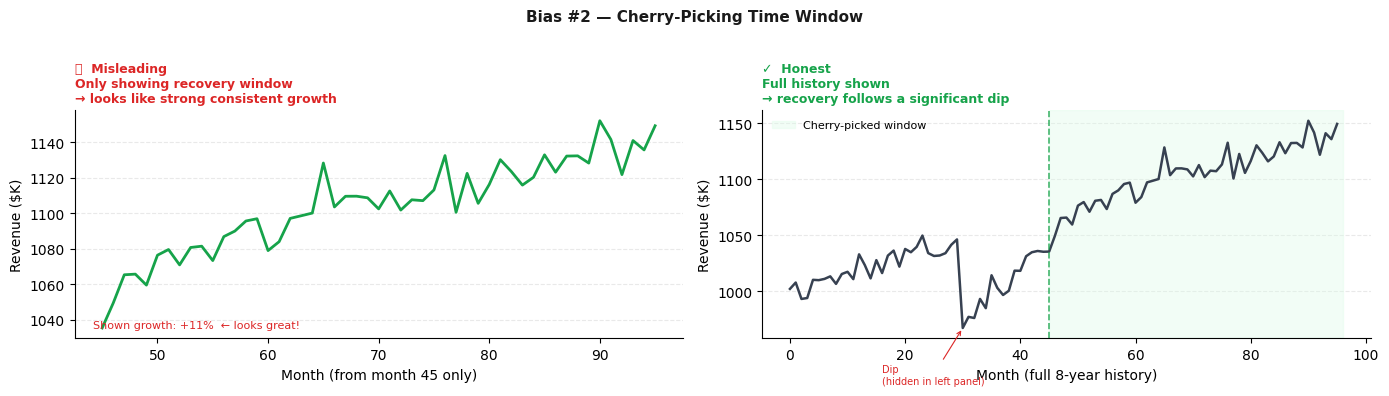

In [4]:
# Longer series with a dip then recovery
T_long = 96
m_long = np.arange(T_long)
rev_long = (
    1000
    + m_long * 1.5
    + np.where((m_long >= 30) & (m_long <= 50), -80 + (m_long - 30) * 4, 0)
    + np.random.randn(T_long) * 8
)
cherry_start = 45   # only show recovery part

fig, axes = make_pair(
    'Only showing recovery window\n→ looks like strong consistent growth',
    'Full history shown\n→ recovery follows a significant dip'
)

# Misleading: cherry-picked
ax = axes[0]
ax.plot(m_long[cherry_start:], rev_long[cherry_start:],
        color='#16A34A', linewidth=2.0)
ax.set_xlabel('Month (from month 45 only)')
ax.set_ylabel('Revenue ($K)')
cherry_growth = (rev_long[-1] - rev_long[cherry_start]) / rev_long[cherry_start] * 100
add_note(ax, f'Shown growth: +{cherry_growth:.0f}%  ← looks great!',
         x=0.03, y=0.08, color='#DC2626', fontsize=8)

# Honest: full history
ax = axes[1]
ax.plot(m_long, rev_long, color='#374151', linewidth=1.8)
ax.axvspan(cherry_start, T_long, color='#DCFCE7', alpha=0.35,
           label='Cherry-picked window')
ax.axvline(cherry_start, color='#16A34A', linewidth=1.2, linestyle='--', alpha=0.8)
dip_idx = int(np.argmin(rev_long[30:55])) + 30
ax.annotate('Dip\n(hidden in left panel)',
            xy=(dip_idx, rev_long[dip_idx]),
            xytext=(dip_idx - 14, rev_long[dip_idx] - 50),
            fontsize=7, color='#DC2626',
            arrowprops=dict(arrowstyle='->', color='#DC2626', lw=0.8))
ax.set_xlabel('Month (full 8-year history)')
ax.set_ylabel('Revenue ($K)')
ax.legend(frameon=False, fontsize=8)

fig.suptitle('Bias #2 — Cherry-Picking Time Window',
             fontsize=11, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Percentage vs Absolute

**Kỹ thuật:** Chọn đơn vị (absolute vs percentage vs per capita) để tối đa hóa impression.

**Ví dụ:**
- *"Tăng 100%"* — nghe đáng sợ, nhưng nếu từ 1 lên 2 thì không có nghĩa gì
- *"Thêm 1 triệu users"* — ấn tượng, nhưng nếu base là 500 triệu thì chỉ +0.2%

**Nguyên tắc:** Khi cả hai đều có ý nghĩa, hiển thị cả hai.

C:\Users\Duy\AppData\Local\Temp\ipykernel_27540\4028404960.py:49: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
c:\Users\Duy\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


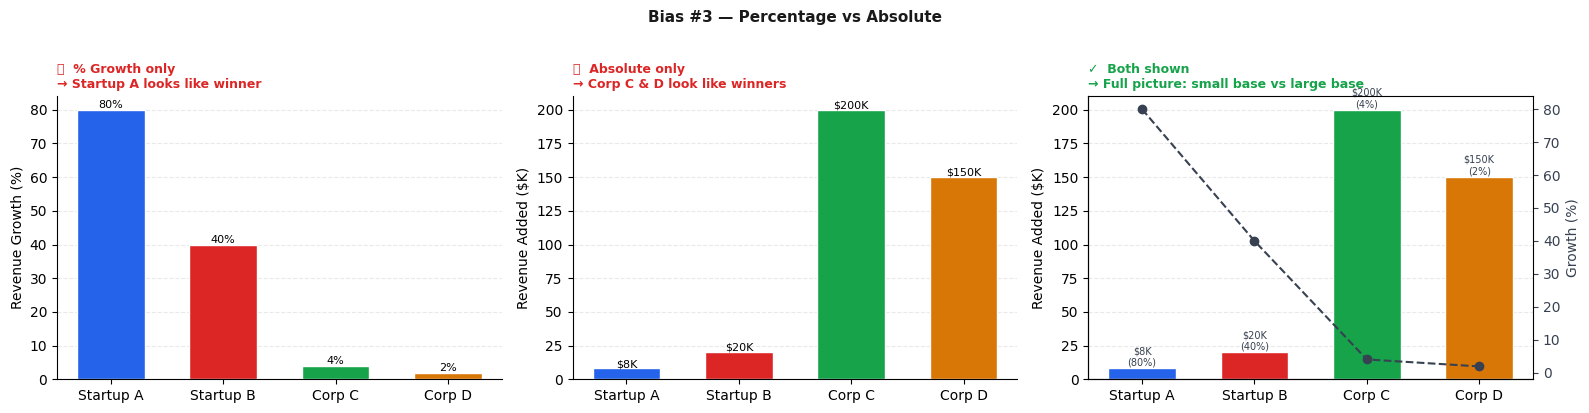

In [5]:
companies  = ['Startup A', 'Startup B', 'Corp C', 'Corp D']
base_rev   = np.array([10,   50,   5000,  8000])   # $K
growth_abs = np.array([8,    20,   200,   150])     # $K added
growth_pct = growth_abs / base_rev * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white')
colors4 = categorical_colors(4)

# Panel 1: % only
ax = axes[0]
bars = ax.bar(companies, growth_pct, color=colors4, edgecolor='white', width=0.6)
for bar, v in zip(bars, growth_pct):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5, f'{v:.0f}%', ha='center', fontsize=8)
ax.set_ylabel('Revenue Growth (%)'); ax.set_title(
    '❌  % Growth only\n→ Startup A looks like winner',
    loc='left', fontsize=9, fontweight='bold', color='#DC2626')
despine(ax); set_grid(ax)

# Panel 2: absolute only
ax = axes[1]
bars = ax.bar(companies, growth_abs, color=colors4, edgecolor='white', width=0.6)
for bar, v in zip(bars, growth_abs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1, f'${v}K', ha='center', fontsize=8)
ax.set_ylabel('Revenue Added ($K)'); ax.set_title(
    '❌  Absolute only\n→ Corp C & D look like winners',
    loc='left', fontsize=9, fontweight='bold', color='#DC2626')
despine(ax); set_grid(ax)

# Panel 3: both
ax = axes[2]
x = np.arange(len(companies))
ax.bar(x, growth_abs, color=colors4, edgecolor='white', width=0.6)
ax2 = ax.twinx()
ax2.plot(x, growth_pct, 'o--', color='#374151', linewidth=1.5, markersize=6)
ax2.set_ylabel('Growth (%)', color='#374151')
ax2.tick_params(colors='#374151')
ax.set_xticks(x); ax.set_xticklabels(companies)
for i, (a, p) in enumerate(zip(growth_abs, growth_pct)):
    ax.text(i, a + 2, f'${a}K\n({p:.0f}%)', ha='center', fontsize=7, color='#374151')
ax.set_ylabel('Revenue Added ($K)'); ax.set_title(
    '✓  Both shown\n→ Full picture: small base vs large base',
    loc='left', fontsize=9, fontweight='bold', color='#16A34A')
despine(ax); set_grid(ax)

fig.suptitle('Bias #3 — Percentage vs Absolute',
             fontsize=11, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Dual Axis Manipulation

Bằng cách scale hai trục độc lập, bạn có thể tạo ra bất kỳ mức độ "correlation" nào — kể cả khi hai series không liên quan gì đến nhau.

**Rule of thumb:** Tránh dual axis. Nếu buộc phải dùng: label rõ, không force scale để tạo correlation giả.

**Thay thế tốt hơn:** Index cả hai series về base = 100 trên single axis.

C:\Users\Duy\AppData\Local\Temp\ipykernel_27540\3111364521.py:47: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()


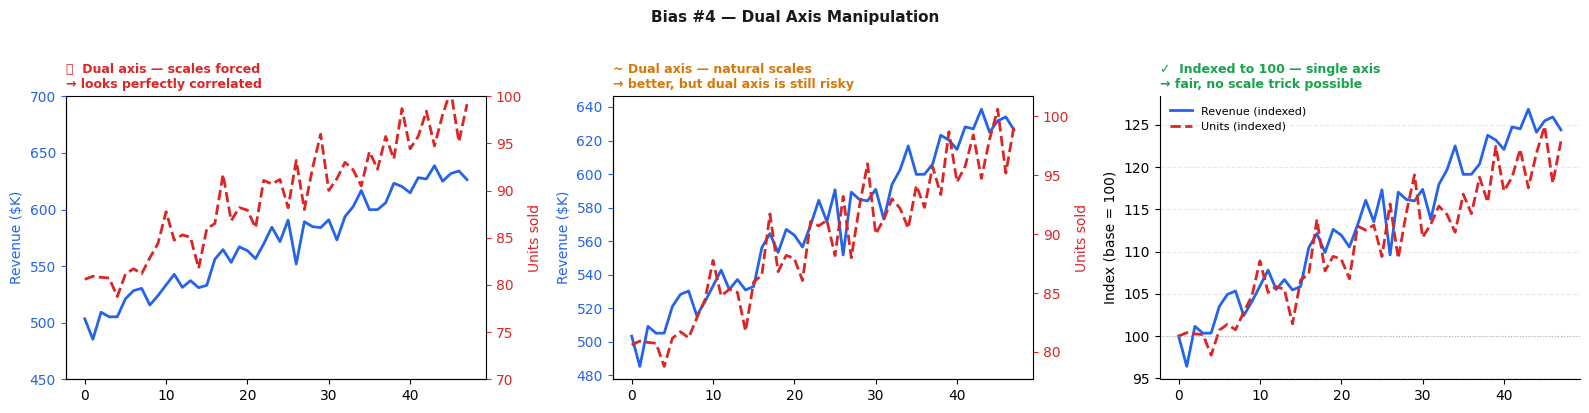

In [6]:
from vizint.comparison.relative import index_to_base

fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white')

# Misleading: forced scale to fake correlation
ax = axes[0]
ax2 = ax.twinx()
ax.plot(months, product_a, color='#2563EB', linewidth=2.0, label='Revenue ($K)')
ax2.plot(months, product_b, color='#DC2626', linewidth=2.0, linestyle='--', label='Units')
ax.set_ylim(450, 700); ax2.set_ylim(70, 100)   # manually aligned to look correlated
ax.set_ylabel('Revenue ($K)', color='#2563EB')
ax2.set_ylabel('Units sold', color='#DC2626')
ax.tick_params(axis='y', colors='#2563EB')
ax2.tick_params(axis='y', colors='#DC2626')
ax.set_title('❌  Dual axis — scales forced\n→ looks perfectly correlated',
             loc='left', fontsize=9, fontweight='bold', color='#DC2626')
despine(ax)

# Better dual axis: natural scales
ax = axes[1]
ax2 = ax.twinx()
ax.plot(months, product_a, color='#2563EB', linewidth=2.0)
ax2.plot(months, product_b, color='#DC2626', linewidth=2.0, linestyle='--')
ax.set_ylabel('Revenue ($K)', color='#2563EB')
ax2.set_ylabel('Units sold', color='#DC2626')
ax.tick_params(axis='y', colors='#2563EB')
ax2.tick_params(axis='y', colors='#DC2626')
ax.set_title('~ Dual axis — natural scales\n→ better, but dual axis is still risky',
             loc='left', fontsize=9, fontweight='bold', color='#D97706')
despine(ax)

# Best: indexed single axis
ax = axes[2]
a_idx = index_to_base(product_a, 0, 100)
b_idx = index_to_base(product_b, 0, 100)
ax.plot(months, a_idx, color='#2563EB', linewidth=2.0, label='Revenue (indexed)')
ax.plot(months, b_idx, color='#DC2626', linewidth=2.0, linestyle='--', label='Units (indexed)')
ax.axhline(100, color='#9CA3AF', linewidth=0.8, linestyle=':', alpha=0.7)
ax.set_ylabel('Index (base = 100)')
ax.legend(frameon=False, fontsize=8)
ax.set_title('✓  Indexed to 100 — single axis\n→ fair, no scale trick possible',
             loc='left', fontsize=9, fontweight='bold', color='#16A34A')
despine(ax); set_grid(ax)

fig.suptitle('Bias #4 — Dual Axis Manipulation',
             fontsize=11, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Cumulative vs Period

**Cumulative chart** luôn đi lên — không bao giờ xuống, ngay cả khi growth đang chậm lại hoặc âm.

**Khi nào cumulative hợp lý:** Total users, total revenue, cumulative cases trong dịch tễ.

**Khi nào phải dùng period:** Khi muốn hiểu momentum, acceleration, hay deceleration.

C:\Users\Duy\AppData\Local\Temp\ipykernel_27540\447471327.py:44: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()


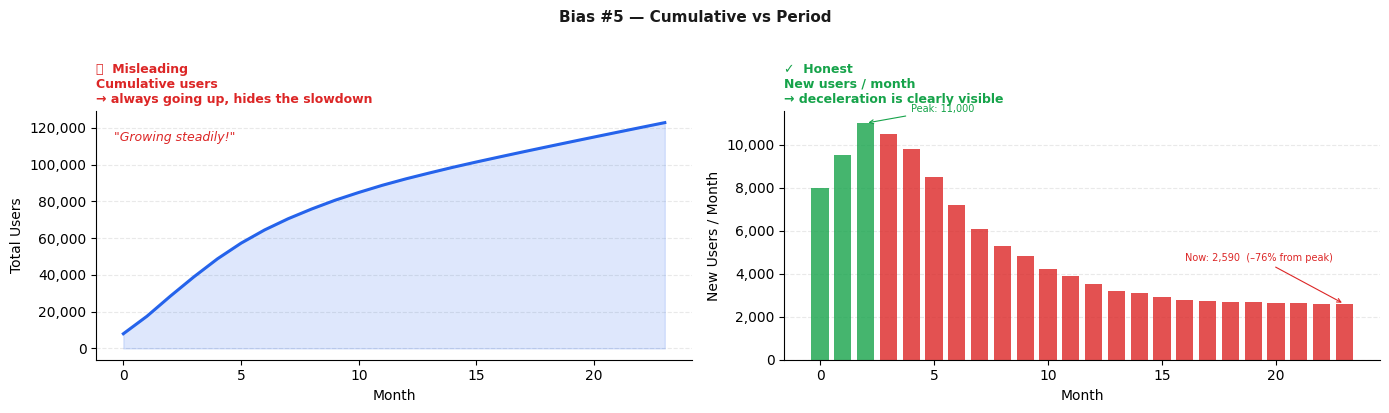

In [7]:
new_users = np.array([
    8000, 9500, 11000, 10500, 9800, 8500,
    7200, 6100, 5300,  4800,  4200, 3900,
    3500, 3200, 3100,  2900,  2800, 2750,
    2700, 2680, 2650,  2630,  2610, 2590,
])
cum_users = np.cumsum(new_users)
m24 = np.arange(len(new_users))

fig, axes = make_pair(
    'Cumulative users\n→ always going up, hides the slowdown',
    'New users / month\n→ deceleration is clearly visible'
)

# Misleading: cumulative
ax = axes[0]
ax.fill_between(m24, cum_users, color='#2563EB', alpha=0.15)
ax.plot(m24, cum_users, color='#2563EB', linewidth=2.2)
ax.set_xlabel('Month'); ax.set_ylabel('Total Users')
format_thousands(ax, 'y')
add_note(ax, '"Growing steadily!"', x=0.03, y=0.92,
         color='#DC2626', fontsize=9, style='italic')

# Honest: period
ax = axes[1]
bar_colors = ['#DC2626' if (i > 0 and v < new_users[i-1]) else '#16A34A'
              for i, v in enumerate(new_users)]
ax.bar(m24, new_users, color=bar_colors, width=0.75, alpha=0.8)
ax.set_xlabel('Month'); ax.set_ylabel('New Users / Month')
format_thousands(ax, 'y')
ax.annotate(f'Peak: {new_users.max():,}',
            xy=(np.argmax(new_users), new_users.max()),
            xytext=(np.argmax(new_users) + 2, new_users.max() + 500),
            fontsize=7, color='#16A34A',
            arrowprops=dict(arrowstyle='->', color='#16A34A', lw=0.8))
ax.annotate(f'Now: {new_users[-1]:,}  (–{(1-new_users[-1]/new_users.max())*100:.0f}% from peak)',
            xy=(len(new_users)-1, new_users[-1]),
            xytext=(len(new_users)-8, new_users[-1] + 2000),
            fontsize=7, color='#DC2626',
            arrowprops=dict(arrowstyle='->', color='#DC2626', lw=0.8))

fig.suptitle('Bias #5 — Cumulative vs Period',
             fontsize=11, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Sample Size Blindness

**Kỹ thuật:** Trình bày tỷ lệ % mà không nêu sample size (n).

80% success rate nghe impressive — nhưng nếu n=5 thì không có ý nghĩa thống kê.

**Nguyên tắc:** Luôn hiển thị n cùng với % — và thêm confidence interval khi n nhỏ.

C:\Users\Duy\AppData\Local\Temp\ipykernel_27540\1204359683.py:50: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
c:\Users\Duy\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


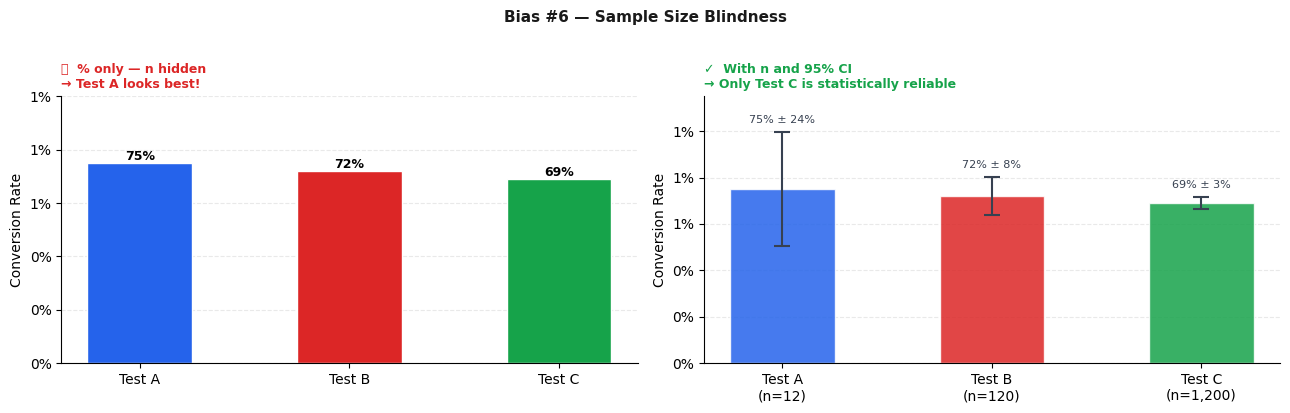

In [8]:
tests = {
    'Test A': {'pct': 0.75, 'n': 12},
    'Test B': {'pct': 0.72, 'n': 120},
    'Test C': {'pct': 0.69, 'n': 1200},
}

def ci_95(p, n):
    return 1.96 * np.sqrt(p * (1 - p) / n)

labels = list(tests.keys())
pcts   = [v['pct'] for v in tests.values()]
ns     = [v['n']   for v in tests.values()]
errors = [ci_95(p, n) for p, n in zip(pcts, ns)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor='white')
colors3 = categorical_colors(3)

# Misleading: % only
ax = axes[0]
bars = ax.bar(range(3), pcts, color=colors3, width=0.5, edgecolor='white')
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0); ax.set_ylabel('Conversion Rate')
format_percent(ax, 'y', decimals=0)
for bar, p in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01, f'{p:.0%}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_title('❌  % only — n hidden\n→ Test A looks best!',
             loc='left', fontsize=9, fontweight='bold', color='#DC2626')
despine(ax); set_grid(ax)

# Honest: % + n + CI
ax = axes[1]
bars = ax.bar(range(3), pcts, color=colors3, width=0.5, edgecolor='white',
              alpha=0.85, yerr=errors, capsize=6,
              error_kw=dict(ecolor='#374151', lw=1.5, capthick=1.5))
ax.set_xticks(range(3))
ax.set_xticklabels([f'{l}\n(n={n:,})' for l, n in zip(labels, ns)])
ax.set_ylim(0, 1.15); ax.set_ylabel('Conversion Rate')
format_percent(ax, 'y', decimals=0)
for i, (p, e) in enumerate(zip(pcts, errors)):
    ax.text(i, p + e + 0.04, f'{p:.0%} ± {e:.0%}',
            ha='center', fontsize=8, color='#374151')
ax.set_title('✓  With n and 95% CI\n→ Only Test C is statistically reliable',
             loc='left', fontsize=9, fontweight='bold', color='#16A34A')
despine(ax); set_grid(ax)

fig.suptitle('Bias #6 — Sample Size Blindness',
             fontsize=11, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Misleading Baseline — Area Chart không từ 0

Area chart dùng **diện tích** để encode magnitude.
Khi baseline không phải 0, diện tích không còn tỷ lệ với giá trị thực.

**Quy tắc cứng:** Area chart phải bắt đầu từ 0. Không có ngoại lệ.

C:\Users\Duy\AppData\Local\Temp\ipykernel_27540\1352408904.py:30: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()


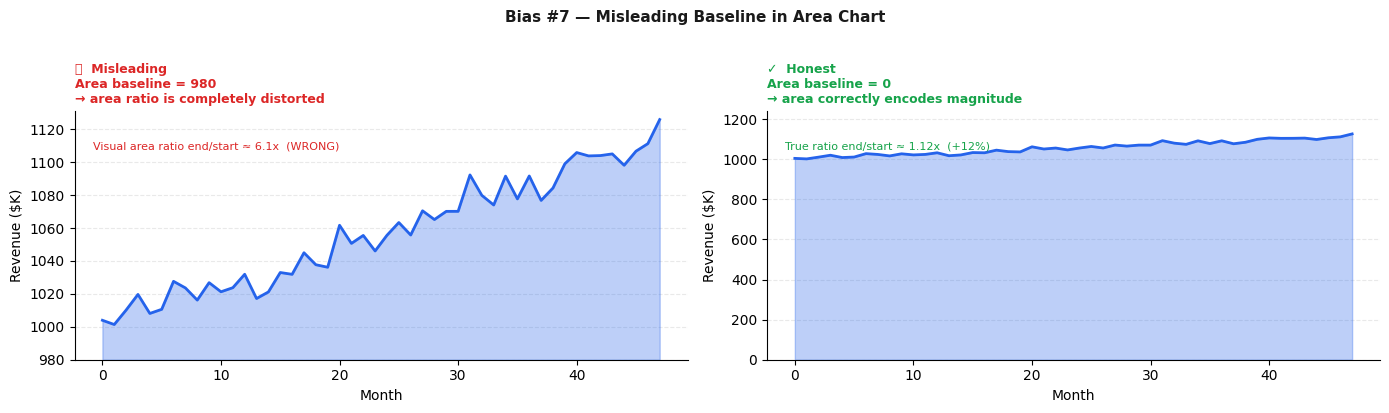

In [9]:
fig, axes = make_pair(
    'Area baseline = 980\n→ area ratio is completely distorted',
    'Area baseline = 0\n→ area correctly encodes magnitude'
)

v_start, v_end = revenue[0], revenue[-1]

# Misleading
ax = axes[0]
ax.fill_between(months, revenue, 980, color='#2563EB', alpha=0.3)
ax.plot(months, revenue, color='#2563EB', linewidth=2.0)
ax.set_ylim(980, revenue.max() + 5)
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($K)')
fake_ratio = (v_end - 980) / (v_start - 980)
add_note(ax, f'Visual area ratio end/start ≈ {fake_ratio:.1f}x  (WRONG)',
         x=0.03, y=0.88, color='#DC2626', fontsize=8)

# Honest
ax = axes[1]
ax.fill_between(months, revenue, 0, color='#2563EB', alpha=0.3)
ax.plot(months, revenue, color='#2563EB', linewidth=2.0)
ax.set_ylim(0, revenue.max() * 1.1)
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($K)')
true_ratio = v_end / v_start
add_note(ax, f'True ratio end/start ≈ {true_ratio:.2f}x  (+{(true_ratio-1)*100:.0f}%)',
         x=0.03, y=0.88, color='#16A34A', fontsize=8)

fig.suptitle('Bias #7 — Misleading Baseline in Area Chart',
             fontsize=11, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Simpson's Paradox

**Simpson's Paradox** = một trend xuất hiện trong aggregate data bị **đảo chiều hoàn toàn** khi nhìn vào từng subgroup.

**Ví dụ kinh điển:** UC Berkeley 1973 — aggregate cho thấy bias chống phụ nữ trong admission. Nhưng khi nhìn từng department, hầu hết đều admit phụ nữ với tỷ lệ **cao hơn** nam giới.

**Tại sao xảy ra:** Confounding variable — treatment được áp dụng nhiều hơn cho nhóm có outcome tự nhiên thấp hơn.

C:\Users\Duy\AppData\Local\Temp\ipykernel_27540\3204738331.py:81: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
c:\Users\Duy\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


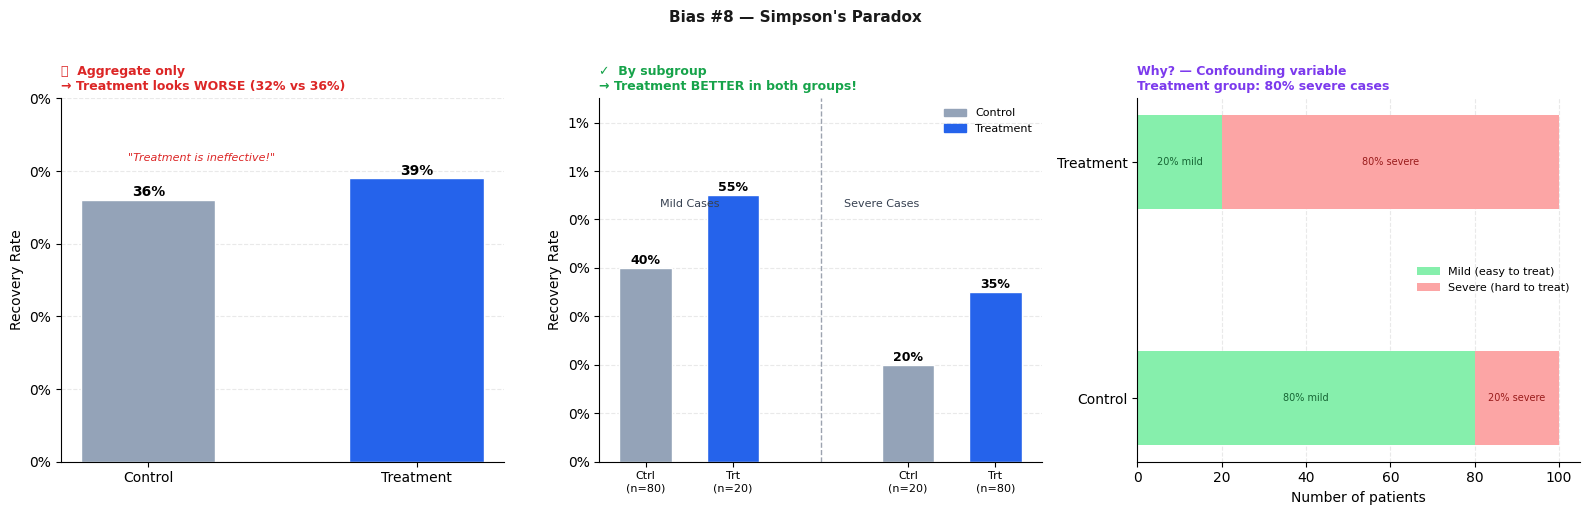

In [10]:
# Recovery rates
# Control : 80 mild (40%) + 20 severe (20%)
# Treatment: 20 mild (55%) + 80 severe (35%)
ctrl_mild_n,  ctrl_mild_r  = 80,  0.40
ctrl_sev_n,   ctrl_sev_r   = 20,  0.20
trt_mild_n,   trt_mild_r   = 20,  0.55
trt_sev_n,    trt_sev_r    = 80,  0.35

ctrl_overall = (ctrl_mild_n*ctrl_mild_r + ctrl_sev_n*ctrl_sev_r) / (ctrl_mild_n + ctrl_sev_n)
trt_overall  = (trt_mild_n *trt_mild_r  + trt_sev_n *trt_sev_r)  / (trt_mild_n  + trt_sev_n)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='white')

# Panel 1: Aggregate — treatment looks WORSE
ax = axes[0]
bars = ax.bar(['Control', 'Treatment'], [ctrl_overall, trt_overall],
              color=['#94A3B8', '#2563EB'], width=0.5, edgecolor='white')
for bar, v in zip(bars, [ctrl_overall, trt_overall]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005, f'{v:.0%}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 0.50); ax.set_ylabel('Recovery Rate')
format_percent(ax, 'y', decimals=0)
ax.set_title('❌  Aggregate only\n→ Treatment looks WORSE (32% vs 36%)',
             loc='left', fontsize=9, fontweight='bold', color='#DC2626')
add_note(ax, '"Treatment is ineffective!"',
         x=0.15, y=0.85, color='#DC2626', fontsize=8, style='italic')
despine(ax); set_grid(ax)

# Panel 2: By subgroup — treatment BETTER in both
ax = axes[1]
x     = np.array([0, 1, 3, 4])
rates = [ctrl_mild_r, trt_mild_r, ctrl_sev_r, trt_sev_r]
cols  = ['#94A3B8', '#2563EB', '#94A3B8', '#2563EB']
bars  = ax.bar(x, rates, color=cols, width=0.6, edgecolor='white')
for bar, v in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008, f'{v:.0%}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Ctrl\n(n=80)', 'Trt\n(n=20)',
                    'Ctrl\n(n=20)', 'Trt\n(n=80)'], fontsize=8)
ax.set_ylim(0, 0.75); ax.set_ylabel('Recovery Rate')
format_percent(ax, 'y', decimals=0)
ax.axvline(2, color='#9CA3AF', linewidth=1.0, linestyle='--')
ax.text(0.5, 0.70, 'Mild Cases', ha='center', fontsize=8, color='#374151',
        transform=ax.get_xaxis_transform())
ax.text(2.7, 0.70, 'Severe Cases', ha='center', fontsize=8, color='#374151',
        transform=ax.get_xaxis_transform())
ax.set_title('✓  By subgroup\n→ Treatment BETTER in both groups!',
             loc='left', fontsize=9, fontweight='bold', color='#16A34A')
ax.legend(handles=[
    mpatches.Patch(color='#94A3B8', label='Control'),
    mpatches.Patch(color='#2563EB', label='Treatment'),
], frameon=False, fontsize=8)
despine(ax); set_grid(ax)

# Panel 3: Why — confounding (case mix)
ax = axes[2]
ax.barh(['Control', 'Treatment'], [ctrl_mild_n, trt_mild_n],
        color='#86EFAC', height=0.4, label='Mild (easy to treat)')
ax.barh(['Control', 'Treatment'], [ctrl_sev_n, trt_sev_n],
        left=[ctrl_mild_n, trt_mild_n],
        color='#FCA5A5', height=0.4, label='Severe (hard to treat)')
ax.set_xlabel('Number of patients')
ax.set_title('Why? — Confounding variable\nTreatment group: 80% severe cases',
             loc='left', fontsize=9, fontweight='bold', color='#7C3AED')
ax.legend(frameon=False, fontsize=8)
for i, (mild, sev) in enumerate([
    (ctrl_mild_n, ctrl_sev_n), (trt_mild_n, trt_sev_n)
]):
    total = mild + sev
    ax.text(mild/2, i, f'{mild/total:.0%} mild',
            ha='center', va='center', fontsize=7, color='#166534')
    ax.text(mild + sev/2, i, f'{sev/total:.0%} severe',
            ha='center', va='center', fontsize=7, color='#991B1B')
despine(ax); set_grid(ax, which='x')

fig.suptitle("Bias #8 — Simpson's Paradox",
             fontsize=11, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Honest Chart Checklist

Chạy qua checklist này trước khi publish bất kỳ chart nào.

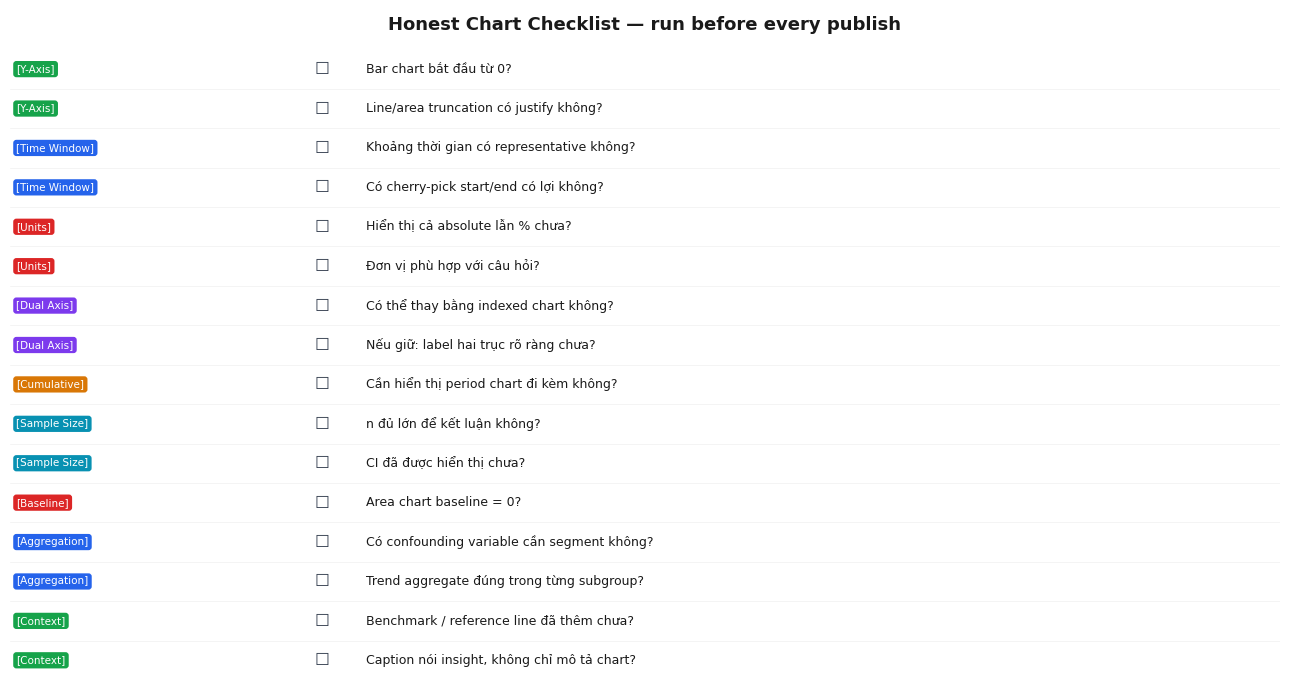

In [11]:
checklist = [
    ('Y-Axis',       'Bar chart bắt đầu từ 0?'),
    ('Y-Axis',       'Line/area truncation có justify không?'),
    ('Time Window',  'Khoảng thời gian có representative không?'),
    ('Time Window',  'Có cherry-pick start/end có lợi không?'),
    ('Units',        'Hiển thị cả absolute lẫn % chưa?'),
    ('Units',        'Đơn vị phù hợp với câu hỏi?'),
    ('Dual Axis',    'Có thể thay bằng indexed chart không?'),
    ('Dual Axis',    'Nếu giữ: label hai trục rõ ràng chưa?'),
    ('Cumulative',   'Cần hiển thị period chart đi kèm không?'),
    ('Sample Size',  'n đủ lớn để kết luận không?'),
    ('Sample Size',  'CI đã được hiển thị chưa?'),
    ('Baseline',     'Area chart baseline = 0?'),
    ('Aggregation',  'Có confounding variable cần segment không?'),
    ('Aggregation',  'Trend aggregate đúng trong từng subgroup?'),
    ('Context',      'Benchmark / reference line đã thêm chưa?'),
    ('Context',      'Caption nói insight, không chỉ mô tả chart?'),
]

fig, ax = plt.subplots(figsize=(13, 7), facecolor='white')
ax.set_xlim(0, 10); ax.set_ylim(0, len(checklist) + 1)
ax.axis('off')

categories = sorted(set(c for c, _ in checklist))
cat_colors = dict(zip(categories, categorical_colors(len(categories))))

ax.text(5, len(checklist) + 0.5,
        'Honest Chart Checklist — run before every publish',
        ha='center', fontsize=13, fontweight='bold', color='#1a1a1a')

for i, (cat, question) in enumerate(reversed(checklist)):
    y = i + 0.5
    color = cat_colors[cat]
    ax.text(0.05, y, f'[{cat}]', fontsize=7.5, color='white', va='center',
            bbox=dict(boxstyle='round,pad=0.3', fc=color, ec='none'))
    ax.text(2.4, y, '☐', fontsize=12, va='center', color='#374151')
    ax.text(2.8, y, question, fontsize=9, va='center', color='#1a1a1a')
    ax.axhline(i, color='#f0f0f0', linewidth=0.5)

plt.tight_layout()
plt.show()

---
## Summary

| Bias | Kỹ thuật | Cách nhận ra |
|------|----------|--------------|
| Truncated Y-Axis | Y không từ 0 | Bar chart trông thay đổi lớn nhưng số nhỏ |
| Cherry-picking | Window có lợi | Hỏi: trước và sau khoảng này là gì? |
| % vs Absolute | Chỉ một đơn vị | Hỏi: n là bao nhiêu? Base là bao nhiêu? |
| Dual axis | Scale độc lập | Hai series trông perfectly correlated |
| Cumulative | Ẩn period âm | Chart chỉ đi lên dù growth chậm |
| Sample size | % không có n | Không có CI, không có n trên chart |
| Misleading baseline | Area không từ 0 | Fill không bắt đầu từ đáy |
| Simpson's paradox | Chỉ aggregate | Hỏi: có subgroup quan trọng nào không? |

---

### Key Takeaway

> Misleading visualization thường không phải là **nói dối** — nó là **nói sự thật một phần**.
> Số liệu có thể chính xác 100% nhưng chart vẫn mislead nếu context bị ẩn đi.
>
> Người tạo chart có trách nhiệm chủ động cung cấp context —
> baseline, sample size, time window đầy đủ, subgroup breakdown —
> ngay cả khi không ai yêu cầu.

**Next →** `08_visualization_storytelling.ipynb` — Kết hợp tất cả: từ raw data đến một câu chuyện hoàn chỉnh.